In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os


feature_path = os.path.abspath(r"C:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor")
# feature_path = os.path.abspath('/Users/alexg/Documents/Documents/Prize-Picks-Prop-Predictor')
if feature_path not in sys.path:
    sys.path.append(feature_path)

from FEATURE_ENGINEERING.features import *
from PROPS_EV.calculateEVS import *

### Load Model

In [2]:
model = joblib.load('Models/xgbModel.pkl')
features = joblib.load('Models/top_features.pkl')

### Load Data

In [3]:
pd.set_option('display.max_columns', None)
eplison = 0.000001

s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s25['EXPECTED_USAGE_MIN'] = s25['USG_PCT_ROLLING_AVG_5'] * (s25['MIN_ROLLING_AVG_5'] + eplison)

s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s24['EXPECTED_USAGE_MIN'] = s24['USG_PCT_ROLLING_AVG_5'] * (s24['MIN_ROLLING_AVG_5'] + eplison)
df = pd.concat([s25, s24]).sort_values(by='GAME_DATE')


date = '2024-10-31'
df = df[df['GAME_DATE'] < date]

backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/singleBookies.csv')

dfsData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')
dfsData = dfsData[(dfsData['BOOKMAKER'] == 'prizepicks') & (dfsData['GAME_DATE'] == date) & (dfsData['CATEGORY'] == 'player_points')]

dfsData.head()

C:\Users\alexg\AppData\Local\Temp\ipykernel_7992\277039639.py:17: DtypeWarning: Columns (11,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  dfsData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,NAME,CATEGORY,BOOKMAKER,SIDE,LINE,ODDS,HOME_TEAM,AWAY_TEAM,game_id,commence_time,GAME_DATE,period_id,fair_line,fair_odds,OVER/ODDS
6199,6199,6199,6199,Bobby Portis,player_points,prizepicks,over,13.5,-137,Memphis Grizzlies,Milwaukee Bucks,189d69ff1460fe7810e1f523220f2a4c,2024-11-01T00:10:00Z,2024-10-31,NaN,NaN,NaN,over
6212,6212,6212,6212,Taurean Prince,player_points,prizepicks,under,8.0,-137,Memphis Grizzlies,Milwaukee Bucks,189d69ff1460fe7810e1f523220f2a4c,2024-11-01T00:10:00Z,2024-10-31,NaN,NaN,NaN,under
6214,6214,6214,6214,Taurean Prince,player_points,prizepicks,over,8.0,-137,Memphis Grizzlies,Milwaukee Bucks,189d69ff1460fe7810e1f523220f2a4c,2024-11-01T00:10:00Z,2024-10-31,NaN,NaN,NaN,over
6215,6215,6215,6215,Gary Trent Jr,player_points,prizepicks,over,12.0,-137,Memphis Grizzlies,Milwaukee Bucks,189d69ff1460fe7810e1f523220f2a4c,2024-11-01T00:10:00Z,2024-10-31,NaN,NaN,NaN,over
6216,6216,6216,6216,Brook Lopez,player_points,prizepicks,under,12.5,-137,Memphis Grizzlies,Milwaukee Bucks,189d69ff1460fe7810e1f523220f2a4c,2024-11-01T00:10:00Z,2024-10-31,NaN,NaN,NaN,under


In [4]:
results = prizepickspairsEV(
    data=df,
    bookmakers=dfsData,
    model=model,
    features=features,
    stake=100,
    simulations=10000
)
results.sort_values(by='EV%', ascending=False).tail(10)

Processing PrizePicks pairs...


,PLAYER 1,CATEGORY 1,BOOKMAKER 1,ODDS 1,LINE 1,PREDICTION 1,OVER% 1,UNDER% 1,CONFIDENCE INTERVAL 1,PLAYER 2,CATEGORY 2,BOOKMAKER 2,ODDS 2,LINE 2,PREDICTION 2,OVER% 2,UNDER% 2,CONFIDENCE INTERVAL 2,TYPE,PROBABILITY,EV%
337,Lauri Markkanen,player_points,prizepicks,-137,21.5,15.50,0.124,0.876,"(5.3, 25.8)",James Harden,player_points,prizepicks,-137,23.5,24.56,0.587,0.413,"(14.3, 35.0)",OVER/UNDER,0.0513,-0.846
37,Taurean Prince,player_points,prizepicks,-137,8.0,8.48,0.587,0.413,"(0.8, 20.3)",Lauri Markkanen,player_points,prizepicks,-137,21.5,15.50,0.124,0.876,"(5.3, 25.8)",UNDER/OVER,0.0513,-0.846
328,Lauri Markkanen,player_points,prizepicks,-137,21.5,15.50,0.124,0.876,"(5.3, 25.8)",Victor Wembanyama,player_points,prizepicks,-137,23.5,21.28,0.398,0.602,"(5.8, 37.2)",OVER/OVER,0.0494,-0.852
331,Lauri Markkanen,player_points,prizepicks,-137,21.5,15.50,0.124,0.876,"(5.3, 25.8)",Norman Powell,player_points,prizepicks,-137,19.5,17.75,0.384,0.616,"(6.2, 29.4)",OVER/OVER,0.0477,-0.857
275,Alperen Sengun,player_points,prizepicks,-137,18.0,16.67,0.371,0.629,"(9.2, 24.1)",Lauri Markkanen,player_points,prizepicks,-137,21.5,15.50,0.124,0.876,"(5.3, 25.8)",OVER/OVER,0.0461,-0.862
327,Lauri Markkanen,player_points,prizepicks,-137,21.5,15.50,0.124,0.876,"(5.3, 25.8)",Jeremy Sochan,player_points,prizepicks,-137,16.0,13.95,0.349,0.651,"(3.4, 25.1)",OVER/OVER,0.0434,-0.870
333,Lauri Markkanen,player_points,prizepicks,-137,21.5,15.50,0.124,0.876,"(5.3, 25.8)",Devin Booker,player_points,prizepicks,-137,24.5,21.18,0.334,0.666,"(5.8, 36.8)",OVER/OVER,0.0415,-0.875
329,Lauri Markkanen,player_points,prizepicks,-137,21.5,15.50,0.124,0.876,"(5.3, 25.8)",Julian Champagnie,player_points,prizepicks,-137,9.5,11.94,0.704,0.296,"(3.3, 21.4)",OVER/UNDER,0.0368,-0.890
194,Jalen Green,player_points,prizepicks,-137,23.5,27.46,0.720,0.280,"(13.9, 40.8)",Lauri Markkanen,player_points,prizepicks,-137,21.5,15.50,0.124,0.876,"(5.3, 25.8)",UNDER/OVER,0.0348,-0.896
12,Bobby Portis,player_points,prizepicks,-137,13.5,10.37,0.243,0.757,"(2.4, 18.9)",Lauri Markkanen,player_points,prizepicks,-137,21.5,15.50,0.124,0.876,"(5.3, 25.8)",OVER/OVER,0.0302,-0.910


## Single game backtest for single bets

In [15]:
def backtestSingle(data, backtestData, gameDate):
    data = data[data['GAME_DATE'] <= gameDate]
    backtestData = backtestData[(backtestData['CATEGORY'] == 'points') & (backtestData['GAME_DATE'] == gameDate)]
    if backtestData.empty:
        print(f"No bets found for {gameDate}")
        return pd.DataFrame()

    results = single_bet(
    data=data,
    bookmakers=backtestData,
    model=model,
    features=features,
    stake=100,
    simulations=10000)
    evData = results.sort_values(by='EV%', ascending=False).head(10)
    results = []

    for idx, row in evData.iterrows():
        player = row['NAME']
        bookmaker = row['BOOKMAKER']
        side = row['SIDE']
        line = row['LINE']
        odds = row['ODDS']
        pred = row['PREDICTION']
        
        playerData = data[data['PLAYER_NAME'] == player]

        if playerData.empty:
            print(f"Player {player} not found in data for {gameDate}")
            continue

        actual = playerData['PTS'].iloc[-1]
        edge = pred - line
        
        if side == 'over':
            recommendation = 1 if (pred > line and abs(edge) > 4) else 0
        elif side == 'under':
            recommendation = 1 if (pred < line and abs(edge) > 4) else 0
        else:
            recommendation = 0

        if side == 'over':
            won = 1 if actual > line else 0
        elif side == 'under':
            won = 1 if actual < line else 0
        else:
            won = 0

        results.append({
            'player': player, 
            'bookmaker': bookmaker, 
            'side': side, 
            'line': line, 
            'odds': odds, 
            'pred': pred, 
            'actual': actual,
            'edge': edge,
            'recommendation': recommendation,
            'won': won,
            'date': gameDate
        })

    return pd.DataFrame(results)

results = backtestSingle(df, backtestData, '2024-10-31')

# Calculate metrics
if not results.empty:
    # Overall metrics
    total_bets = len(results)
    total_wins = results['won'].sum()
    win_rate = results['won'].mean()
    
    # Metrics for recommended bets only
    recommended = results[results['recommendation'] == 1]
    if not recommended.empty:
        rec_total = len(recommended)
        rec_wins = recommended['won'].sum()
        rec_win_rate = recommended['won'].mean()
        
        print(f"\n--- All Bets ---")
        print(f"Total: {total_bets}, Wins: {total_wins}, Win Rate: {win_rate:.2%}")
        print(f"\n--- Recommended Bets (Edge > 4) ---")
        print(f"Total: {rec_total}, Wins: {rec_wins}, Win Rate: {rec_win_rate:.2%}")
results

Processing single bets...

--- All Bets ---
Total: 10, Wins: 5, Win Rate: 50.00%

--- Recommended Bets (Edge > 4) ---
Total: 6, Wins: 3, Win Rate: 50.00%


,player,bookmaker,side,line,odds,pred,actual,edge,recommendation,won,date
0,Zion Williamson,fanduel,over,13.5,102,20.704443,12,7.204443,1,0,2024-10-31
1,Jalen Green,fanduel,over,20.5,100,27.457573,36,6.957573,1,1,2024-10-31
2,Kyrie Irving,fanduel,under,32.5,-138,23.037926,35,-9.462074,1,0,2024-10-31
3,Keyonte George,espnbet,over,14.5,110,17.464996,10,2.964996,0,0,2024-10-31
4,Jalen Green,espnbet,over,21.5,-105,27.457573,36,5.957573,1,1,2024-10-31
5,Luka Dončić,fanduel,over,26.5,-114,33.216038,24,6.716038,1,0,2024-10-31
6,Daniel Gafford,betrivers,over,8.5,-120,11.748197,14,3.248197,0,1,2024-10-31
7,Keyonte George,fanduel,over,13.5,-130,17.464996,10,3.964996,0,0,2024-10-31
8,Jalen Green,betrivers,over,23.5,-109,27.457573,36,3.957573,0,1,2024-10-31
9,Keldon Johnson,espnbet,under,14.5,-140,10.293529,9,-4.206471,1,1,2024-10-31


In [ ]:
uniqueDates = sorted(s25['GAME_DATE'].unique())
all_results = []

for i, date in enumerate(uniqueDates, 1):
    print(f"Processing {date}... {i}/{len(uniqueDates)}")
    
    try:
        date_results = backtestSingle(df, backtestData, date)
        
        if not date_results.empty:
            all_results.append(date_results)
            print(f"  ✓ Processed {len(date_results)} bets")
        else:
            print(f"  No results for {date}")
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        continue

# Combine all results
if all_results:
    final_results = pd.concat(all_results, ignore_index=True)
    print(f"\n✓ Complete! Total bets analyzed: {len(final_results)}")



## Backtest Metrics for single bets

           COMPREHENSIVE BETTING ANALYSIS

 ALL BETS ANALYSIS:
   Total Bets: 1,598
   Wins: 895
   Hit Rate: 56.01%
   Total Profit: $65,950.00
   Total Staked: $7,990.00
   ROI: 825.41%
   Volatility: $3035.89
   Max Drawdown: $-96240.00
   Sharpe Ratio: 2.155

 RECOMMENDED BETS ANALYSIS (Edge > 4):
   Total Bets: 1,141
   Wins: 722
   Hit Rate: 63.28%
   Total Profit: $-1,455.00
   Total Staked: $5,705.00
   ROI: -25.50%
   Volatility: $2269.49
   Max Drawdown: $-90575.00
   Sharpe Ratio: -0.064


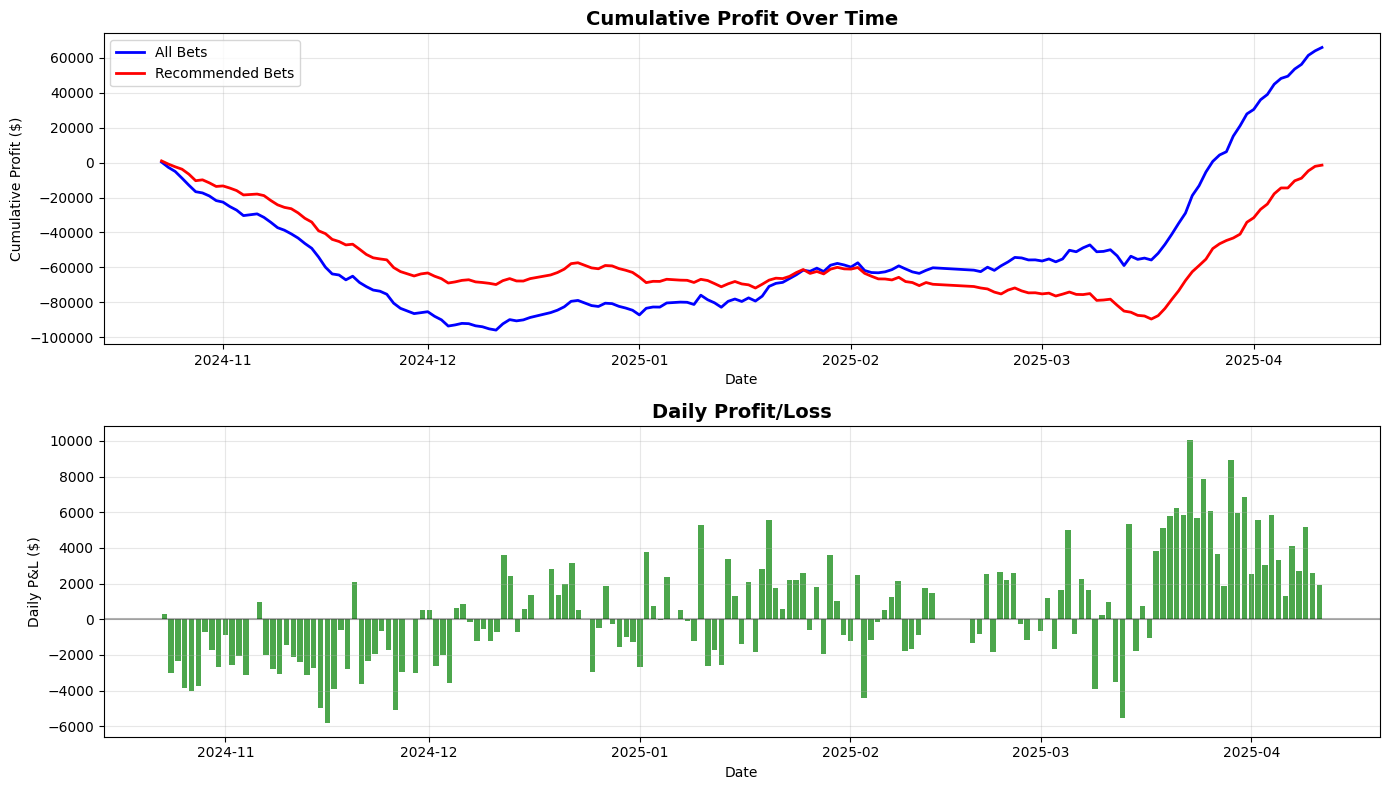

In [112]:
def calculate_advanced_metrics(results_df, stake=5):
    """
    Calculate advanced betting metrics including ROI, volatility, max drawdown, and Sharpe ratio
    """
    if results_df.empty:
        return {}
    
    # Basic calculations
    total_bets = len(results_df)
    total_wins = results_df['won'].sum()
    win_rate = results_df['won'].mean()
    
    # Calculate P&L for each bet
    results_df = results_df.copy()
    results_df['profit'] = results_df.apply(lambda row: 
        (row['odds'] * stake - stake) if row['won'] == 1 else -stake, axis=1)
    
    # Total profit and ROI
    total_profit = results_df['profit'].sum()
    total_staked = total_bets * stake
    roi_percent = (total_profit / total_staked) * 100
    
    # Daily P&L (group by date)
    daily_pnl = results_df.groupby('date')['profit'].sum().reset_index()
    daily_pnl['date'] = pd.to_datetime(daily_pnl['date'])
    daily_pnl = daily_pnl.sort_values('date')
    
    # Volatility (standard deviation of daily P&L)
    volatility = daily_pnl['profit'].std()
    
    # Max drawdown (largest peak-to-trough loss)
    daily_pnl['cumulative_profit'] = daily_pnl['profit'].cumsum()
    daily_pnl['running_max'] = daily_pnl['cumulative_profit'].expanding().max()
    daily_pnl['drawdown'] = daily_pnl['cumulative_profit'] - daily_pnl['running_max']
    max_drawdown = daily_pnl['drawdown'].min()
    
    # Sharpe ratio (assuming 252 trading days per year)
    if volatility > 0:
        daily_return = daily_pnl['profit'].mean()
        sharpe_ratio = (daily_return / volatility) * np.sqrt(252)
    else:
        sharpe_ratio = 0
    
    return {
        'total_bets': total_bets,
        'total_wins': total_wins,
        'win_rate': win_rate,
        'total_profit': total_profit,
        'total_staked': total_staked,
        'roi_percent': roi_percent,
        'volatility': volatility,
        'max_drawdown': max_drawdown,
        'sharpe_ratio': sharpe_ratio,
        'daily_pnl': daily_pnl
    }

# Calculate metrics for all bets
all_metrics = calculate_advanced_metrics(final_results)

# Calculate metrics for recommended bets only
recommended = final_results[final_results['recommendation'] == 1]
rec_metrics = calculate_advanced_metrics(recommended)

# Display comprehensive results
print("=" * 60)
print("           COMPREHENSIVE BETTING ANALYSIS")
print("=" * 60)

if all_metrics:
    print(f"\n ALL BETS ANALYSIS:")
    print(f"   Total Bets: {all_metrics['total_bets']:,}")
    print(f"   Wins: {all_metrics['total_wins']:,}")
    print(f"   Hit Rate: {all_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${all_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${all_metrics['total_staked']:,.2f}")
    print(f"   ROI: {all_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${all_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${all_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {all_metrics['sharpe_ratio']:.3f}")

if rec_metrics:
    print(f"\n RECOMMENDED BETS ANALYSIS (Edge > 4):")
    print(f"   Total Bets: {rec_metrics['total_bets']:,}")
    print(f"   Wins: {rec_metrics['total_wins']:,}")
    print(f"   Hit Rate: {rec_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${rec_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${rec_metrics['total_staked']:,.2f}")
    print(f"   ROI: {rec_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${rec_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${rec_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {rec_metrics['sharpe_ratio']:.3f}")

# Plot cumulative profit over time
if all_metrics and not all_metrics['daily_pnl'].empty:
    plt.figure(figsize=(14, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['cumulative_profit'], 
             linewidth=2, label='All Bets', color='blue')
    if rec_metrics and not rec_metrics['daily_pnl'].empty:
        plt.plot(rec_metrics['daily_pnl']['date'], rec_metrics['daily_pnl']['cumulative_profit'], 
                 linewidth=2, label='Recommended Bets', color='red')
    plt.title('Cumulative Profit Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Profit ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.bar(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['profit'], 
            alpha=0.7, label='Daily P&L', color='green')
    plt.title('Daily Profit/Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Daily P&L ($)')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [124]:
def backtestPrizePicksPairs(data, backtestData, gameDate, edge_threshold=0.05):
    data = data[data['GAME_DATE'] <= gameDate]
    backtestData = backtestData[(backtestData['CATEGORY'] == 'points') & (backtestData['GAME_DATE'] == gameDate)]
    
    if backtestData.empty:
        print(f"No bets found for {gameDate}")
        return pd.DataFrame()

    # Get PrizePicks pairs EV calculations
    results = prizepickspairsEV(
        data=data,
        bookmakers=backtestData,
        model=model,
        features=features,
        stake=100,
        simulations=10000
    )
    
    # Sort by EV% and take top pairs
    evData = results.sort_values(by='EV%', ascending=False).head(10)
    
    if evData.empty:
        print(f"No valid pairs found for {gameDate}")
        return pd.DataFrame()
    
    backtest_results = []

    for idx, row in evData.iterrows():
        player1 = row['PLAYER 1']
        player2 = row['PLAYER 2']
        
        line1 = row['LINE 1']
        line2 = row['LINE 2']
        side1 = row['SIDE 1']
        side2 = row['SIDE 2']
        
        pred1 = row['PREDICTION 1']
        pred2 = row['PREDICTION 2']
        
        # Get actual results for both players
        player1Data = data[data['PLAYER_NAME'] == player1]
        player2Data = data[data['PLAYER_NAME'] == player2]

        if player1Data.empty or player2Data.empty:
            print(f"Player data not found for {player1} or {player2} on {gameDate}")
            continue

        actual1 = player1Data['PTS'].iloc[-1]
        actual2 = player2Data['PTS'].iloc[-1]
        
        # Calculate edges for each leg
        edge1 = pred1 - line1
        edge2 = pred2 - line2
        
        # Determine if each leg should be recommended based on edge
        if side1 == 'over':
            rec1 = 1 if (pred1 > line1 and abs(edge1) > 4) else 0
            won1 = 1 if actual1 > line1 else 0
        elif side1 == 'under':
            rec1 = 1 if (pred1 < line1 and abs(edge1) > 4) else 0
            won1 = 1 if actual1 < line1 else 0
        else:
            rec1 = 0
            won1 = 0

        if side2 == 'over':
            rec2 = 1 if (pred2 > line2 and abs(edge2) > 4) else 0
            won2 = 1 if actual2 > line2 else 0
        elif side2 == 'under':
            rec2 = 1 if (pred2 < line2 and abs(edge2) > 4) else 0
            won2 = 1 if actual2 < line2 else 0
        else:
            rec2 = 0
            won2 = 0
        
        # Overall pair recommendation (both legs must be recommended)
        pair_recommendation = 1 if (rec1 == 1 and rec2 == 1) else 0
        
        # Pair wins only if both legs win
        pair_won = 1 if (won1 == 1 and won2 == 1) else 0
        
        # Calculate combined edge
        combined_edge = abs(edge1) + abs(edge2)

        backtest_results.append({
            'player1': player1,
            'player2': player2,
            'side1': side1,
            'side2': side2,
            'line1': line1,
            'line2': line2,
            'pred1': pred1,
            'pred2': pred2,
            'actual1': actual1,
            'actual2': actual2,
            'edge1': edge1,
            'edge2': edge2,
            'combined_edge': combined_edge,
            'leg1_recommendation': rec1,
            'leg2_recommendation': rec2,
            'leg1_won': won1,
            'leg2_won': won2,
            'pair_recommendation': pair_recommendation,
            'pair_won': pair_won,
            'ev_percent': row['EV%'],
            'probability': row['PROBABILITY'],
            'kelly_full': row['KELLY FULL'],
            'date': gameDate
        })

    return pd.DataFrame(backtest_results)


# Test the function with a specific date
test_results = backtestPrizePicksPairs(df, dfsData, '2024-10-22')

if not test_results.empty:
    print(f"\n--- PrizePicks Pairs Backtest Results ---")
    print(f"Total pairs analyzed: {len(test_results)}")
    
    # Overall metrics
    total_pairs = len(test_results)
    total_wins = test_results['pair_won'].sum()
    win_rate = test_results['pair_won'].mean()
    
    # Metrics for recommended pairs only
    recommended_pairs = test_results[test_results['pair_recommendation'] == 1]
    if not recommended_pairs.empty:
        rec_total = len(recommended_pairs)
        rec_wins = recommended_pairs['pair_won'].sum()
        rec_win_rate = recommended_pairs['pair_won'].mean()
        
        print(f"\n--- All Pairs ---")
        print(f"Total: {total_pairs}, Wins: {total_wins}, Win Rate: {win_rate:.2%}")
        print(f"\n--- Recommended Pairs (Both legs recommended) ---")
        print(f"Total: {rec_total}, Wins: {rec_wins}, Win Rate: {rec_win_rate:.2%}")
        
        # Show top pairs by EV
        print(f"\n--- Top 5 Pairs by EV% ---")
        top_pairs = test_results.sort_values(by='ev_percent', ascending=False).head(5)
        for idx, row in top_pairs.iterrows():
            print(f"{row['player1']} ({row['side1']} {row['line1']}) + {row['player2']} ({row['side2']} {row['line2']})")
            print(f"  EV: {row['ev_percent']:.1%}, Probability: {row['probability']:.1%}, Won: {row['pair_won']}")
    else:
        print("No recommended pairs found")
else:
    print("No pairs data available for this date")

No bets found for 2024-10-22
No pairs data available for this date
